<a href="https://colab.research.google.com/github/Nikhilsankhyan0/Agrisheild-AI/blob/main/XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

Mounted at /content/drive


In [2]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


load models

In [3]:
risk_model = joblib.load(
    "/content/drive/MyDrive/final_Risk_score_model.pkl"
)

regression_scaler = joblib.load(
    "/content/drive/MyDrive/regression_scaler.pkl"
)

xgb_classifier = joblib.load(
    "/content/drive/MyDrive/final_xgb_classifier.pkl"
)

label_encoder = joblib.load(
    "/content/drive/MyDrive/classification_label_encoder.pkl"
)

In [4]:
print("Risk Score Model:")
print(risk_model)

print("\nRegression Scaler:")
print(regression_scaler)

print("\nClassification Model:")
print(xgb_classifier)

print("\nClasses:")
print(label_encoder.classes_)

Risk Score Model:
ElasticNet(alpha=0.01, max_iter=10000, random_state=42)

Regression Scaler:
StandardScaler()

Classification Model:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

Classes:
['Approved' 'Approved with Conditions' 'Rejected']


load test dataset

In [5]:
x_test = pd.read_csv(
    "/content/drive/MyDrive/X_test_encoded.csv"
)

y_test_reg = pd.read_csv(
    "/content/drive/MyDrive/y_test_reg.csv"
).squeeze()

y_test_cls = pd.read_csv(
    "/content/drive/MyDrive/y_test_cls.csv"
).squeeze()

In [6]:
x_test = pd.read_csv(
    "/content/drive/MyDrive/X_test_encoded.csv"
)

y_test_reg = pd.read_csv(
    "/content/drive/MyDrive/y_test_reg.csv"
).squeeze()

y_test_cls = pd.read_csv(
    "/content/drive/MyDrive/y_test_cls.csv"
).squeeze()

scale X_test for Risk Score model

In [7]:
x_test_scaled = regression_scaler.transform(x_test)

print("Scaled test shape:", x_test_scaled.shape)

Scaled test shape: (3000, 259)


In [8]:
x_test_scaled_df = pd.DataFrame(
    x_test_scaled,
    columns=x_test.columns,
    index=x_test.index
)

print(x_test_scaled_df.head())

        Age  Family_Size  Dependents  Farming_Experience_Years  \
0 -0.828945    -1.369414   -1.464049                 -0.651596   
1  0.039050     0.928170    0.261287                  0.292812   
2  2.643032    -0.450381   -0.601381                  0.035246   
3  0.039050     0.009136    1.123955                  0.121101   
4  1.341041    -1.369414   -1.464049                  1.494785   

   Farm_Size_Acres  Soil_Quality_Index  Annual_Rainfall_mm  \
0        -0.354471           -0.214278            0.032147   
1        -0.155316           -1.536579            0.137046   
2        -0.369961           -0.537340           -0.322934   
3        -0.006319            1.288335           -0.340185   
4        -0.384713           -0.086556           -0.475796   

   Average_Temperature_C  Humidity_Percent  Weather_Risk_Index  ...  \
0               0.607808         -0.763018            0.356054  ...   
1              -1.379349          0.028991           -1.397087  ...   
2               0

In [9]:
explainer_reg = shap.LinearExplainer(
    risk_model,
    x_test_scaled_df
)

In [10]:
shap_values_reg = explainer_reg(
    x_test_scaled_df
)

In [11]:
print(shap_values_reg)

.values =
array([[-0.21281736, -0.11577498,  0.06420677, ...,  0.04615902,
        -0.        ,  0.00598458],
       [-0.00437724,  0.06455988, -0.0033793 , ...,  0.04615902,
         0.        ,  0.00598458],
       [ 0.62094311, -0.04364104,  0.03041373, ..., -0.28354824,
         0.        ,  0.00598458],
       ...,
       [ 0.37081497, -0.11577498,  0.06420677, ...,  0.04615902,
         0.        ,  0.00598458],
       [ 0.22490689,  0.02849291, -0.0033793 , ...,  0.04615902,
         0.        ,  0.00598458],
       [-0.06690928,  0.10062685, -0.0033793 , ...,  0.04615902,
         0.        ,  0.00598458]])

.base_values =
array([37.32653434, 37.32653434, 37.32653434, ..., 37.32653434,
       37.32653434, 37.32653434])

.data =
array([[-0.82894476, -1.36941443, -1.46404855, ..., -0.42356689,
         3.8488899 , -0.22699055],
       [ 0.03904953,  0.92817008,  0.26128682, ..., -0.42356689,
        -0.25981517, -0.22699055],
       [ 2.6430324 , -0.45038062, -0.60138087, ...,  2

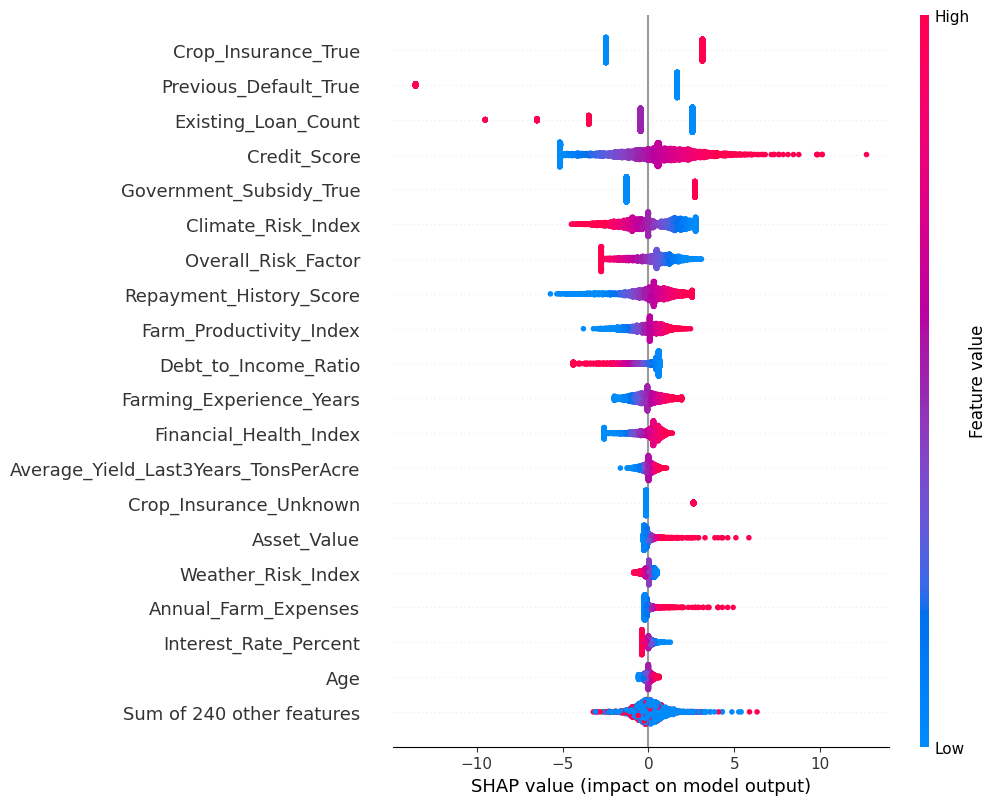

In [12]:
shap.plots.beeswarm(
    shap_values_reg,
    max_display=20
)

feature importance

In [25]:
# ==========================================
# RISK SCORE XAI - FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": x_test_scaled_df.columns,
    "Mean_Absolute_SHAP": np.abs(
        shap_values_reg.values
    ).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("Top 20 Features Affecting Risk Score:")
print(feature_importance.head(20))

Top 20 Features Affecting Risk Score:
                                 Feature  Mean_Absolute_SHAP
0                    Crop_Insurance_True            2.785409
1                  Previous_Default_True            2.631406
2                    Existing_Loan_Count            2.024208
3                           Credit_Score            2.022619
4                Government_Subsidy_True            1.831686
5                     Climate_Risk_Index            1.366448
6                    Overall_Risk_Factor            1.115566
7                Repayment_History_Score            1.027961
8                Farm_Productivity_Index            0.709769
9                   Debt_to_Income_Ratio            0.698345
10              Farming_Experience_Years            0.651882
11                Financial_Health_Index            0.600945
12  Average_Yield_Last3Years_TonsPerAcre            0.277151
13                Crop_Insurance_Unknown            0.265765
14                           Asset_Value       

In [26]:
# ==========================================
# RISK SCORE XAI - FINAL FEATURE SUMMARY
# ==========================================

feature_summary = pd.DataFrame({
    "Feature": x_test_scaled_df.columns,
    "Mean_Absolute_SHAP": np.abs(
        shap_values_reg.values
    ).mean(axis=0),
    "Mean_SHAP": shap_values_reg.values.mean(axis=0)
})

feature_summary = feature_summary.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

feature_summary["Overall_Impact"] = np.where(
    feature_summary["Mean_SHAP"] > 0,
    "Generally increases Risk Score",
    "Generally decreases Risk Score"
)

print(feature_summary.head(15))

                                 Feature  Mean_Absolute_SHAP  Mean_SHAP  \
0                    Crop_Insurance_True            2.785409   0.133002   
1                  Previous_Default_True            2.631406   0.452132   
2                    Existing_Loan_Count            2.024208   0.175038   
3                           Credit_Score            2.022619   0.223499   
4                Government_Subsidy_True            1.831686   0.263403   
5                     Climate_Risk_Index            1.366448   0.119998   
6                    Overall_Risk_Factor            1.115566   0.187235   
7                Repayment_History_Score            1.027961   0.144040   
8                Farm_Productivity_Index            0.709769  -0.037441   
9                   Debt_to_Income_Ratio            0.698345   0.012065   
10              Farming_Experience_Years            0.651882  -0.095083   
11                Financial_Health_Index            0.600945   0.040504   
12  Average_Yield_Last3Ye

explanation for classifying the predictions

In [28]:
explainer_cls = shap.TreeExplainer(
    xgb_classifier
)

shap_values_cls = explainer_cls(
    x_test
)

Understand the SHAP output

In [29]:
print("SHAP values shape:", shap_values_cls.values.shape)

print("Base values shape:", shap_values_cls.base_values.shape)

print("Classes:", label_encoder.classes_)

SHAP values shape: (3000, 259, 3)
Base values shape: (3000, 3)
Classes: ['Approved' 'Approved with Conditions' 'Rejected']


feature importance

Which features does our XGBoost model rely on most when predicting Loan Status?

In [37]:
shap_array = shap_values_cls.values

print("SHAP shape:", shap_array.shape)
print("X_test shape:", x_test.shape)

SHAP shape: (3000, 259, 3)
X_test shape: (3000, 259)


In [38]:
# Mean absolute SHAP across samples and classes

mean_abs_shap = np.abs(shap_array).mean(axis=(0, 2))

classification_feature_importance = pd.DataFrame({
    "Feature": x_test.columns,
    "Mean_Absolute_SHAP": mean_abs_shap
})

classification_feature_importance = (
    classification_feature_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    classification_feature_importance.head(20)
)

                                 Feature  Mean_Absolute_SHAP
0                           Credit_Score            1.316609
1                    Crop_Insurance_True            0.289446
2                Government_Subsidy_True            0.213975
3                    Overall_Risk_Factor            0.202861
4                    Existing_Loan_Count            0.160443
5                   Debt_to_Income_Ratio            0.160386
6                 Financial_Health_Index            0.143243
7                Repayment_History_Score            0.136558
8                     Climate_Risk_Index            0.128585
9                  Previous_Default_True            0.108237
10                  Existing_Loan_Amount            0.100550
11              Farming_Experience_Years            0.081240
12                    Weather_Risk_Index            0.065103
13                Income_Stability_Index            0.063954
14                 Interest_Rate_Percent            0.063632
15               Farm_Pr

global importance graph

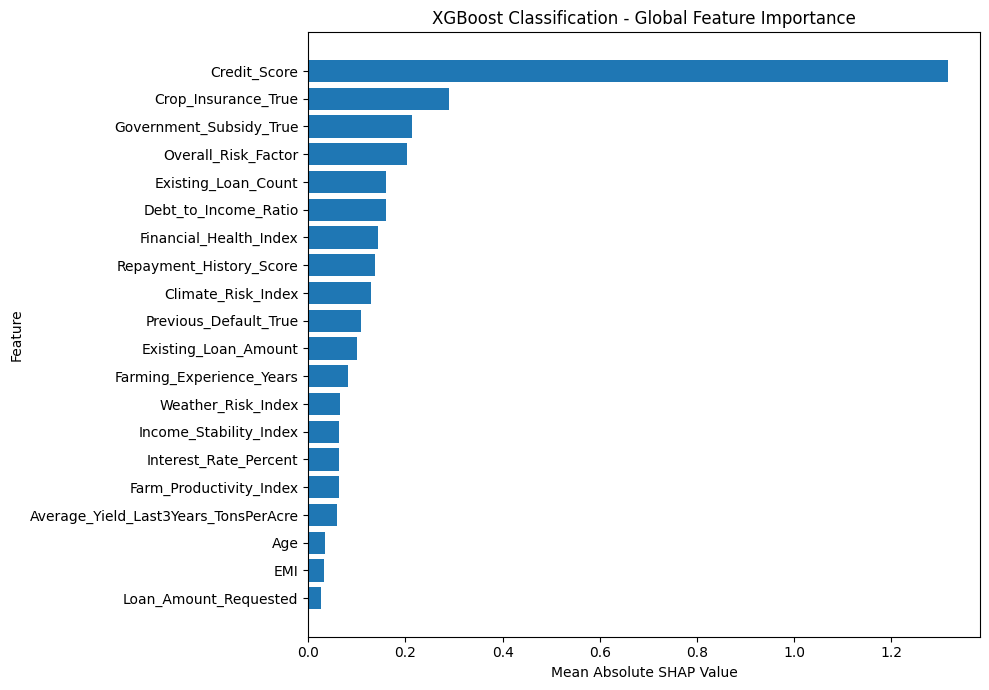

In [39]:
# ==========================================
# GLOBAL CLASSIFICATION FEATURE IMPORTANCE
# ==========================================

top_features = classification_feature_importance.head(20)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Mean_Absolute_SHAP"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("XGBoost Classification - Global Feature Importance")

plt.tight_layout()
plt.show()

class wise importance

In [40]:
# ==========================================
# CLASSIFICATION XAI - CLASS-WISE IMPORTANCE
# ==========================================

classes = label_encoder.classes_

for class_index, class_name in enumerate(classes):

    class_shap = shap_array[:, :, class_index]

    class_importance = pd.DataFrame({
        "Feature": x_test.columns,
        "Mean_Absolute_SHAP": np.abs(class_shap).mean(axis=0)
    })

    class_importance = (
        class_importance
        .sort_values(
            "Mean_Absolute_SHAP",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("\n====================================")
    print(f"CLASS: {class_name}")
    print("====================================")

    print(class_importance.head(10))


CLASS: Approved
                    Feature  Mean_Absolute_SHAP
0              Credit_Score            2.890060
1       Crop_Insurance_True            0.353780
2   Government_Subsidy_True            0.246331
3        Climate_Risk_Index            0.175684
4      Debt_to_Income_Ratio            0.164693
5   Repayment_History_Score            0.152269
6       Existing_Loan_Count            0.144450
7       Overall_Risk_Factor            0.126462
8  Farming_Experience_Years            0.091610
9      Existing_Loan_Amount            0.087925

CLASS: Approved with Conditions
                   Feature  Mean_Absolute_SHAP
0             Credit_Score            0.506931
1      Overall_Risk_Factor            0.166959
2    Previous_Default_True            0.160535
3     Debt_to_Income_Ratio            0.140581
4      Existing_Loan_Count            0.071884
5     Asset_Strength_Index            0.043431
6      Crop_Insurance_True            0.040511
7  Repayment_History_Score            0.037639

Pick one farmer

 Why Approved?

In [42]:
# ==========================================
# INDIVIDUAL FARMER - CLASSIFICATION XAI
# ==========================================

farmer_index = 45

farmer_data = x_test.iloc[[farmer_index]]

predicted_class_encoded = xgb_classifier.predict(
    farmer_data
)[0]

predicted_class = label_encoder.inverse_transform(
    [predicted_class_encoded]
)[0]

print("Predicted Loan Status:", predicted_class)

print(
    "Actual Loan Status:",
    y_test_cls.iloc[farmer_index]
)

Predicted Loan Status: Approved
Actual Loan Status: Approved


Plotting waterfall plot for farmer index 45 and predicted class 'Approved'


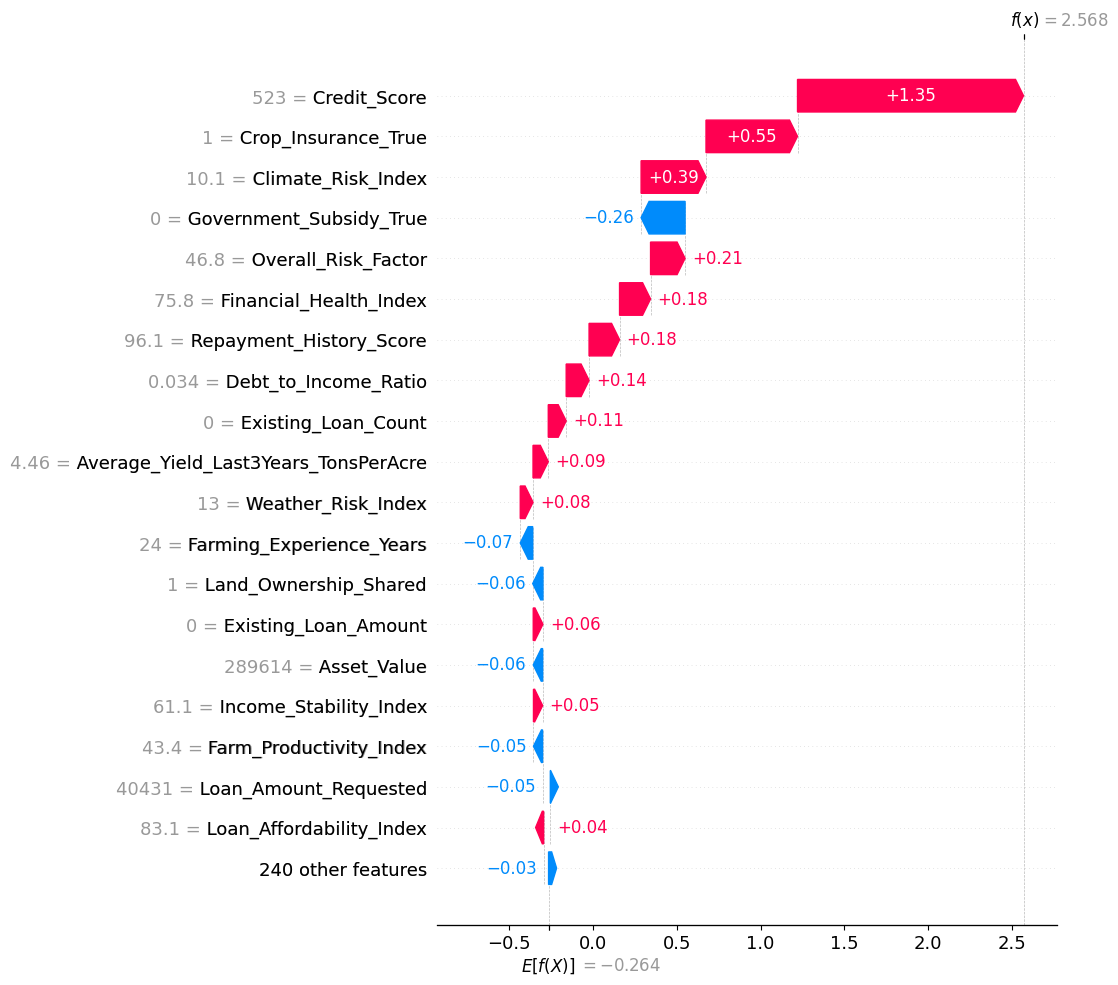

In [44]:
# ==========================================
# INDIVIDUAL FARMER SHAP EXPLANATION
# ==========================================

predicted_class_index = np.where(label_encoder.classes_ == predicted_class)[0][0]


farmer_shap_for_class = shap_values_cls[farmer_index, :, predicted_class_index]

print(f"Plotting waterfall plot for farmer index {farmer_index} and predicted class '{predicted_class}'")
shap.plots.waterfall(
    farmer_shap_for_class,
    max_display=20
)

red towards approval class
blue pushes away from approval

For this particular farmer, the model's Approved prediction was mainly influenced by Credit Score, Crop Insurance, Climate Risk Index, Financial Health, and Repayment History.

***Create the prediction pipeline***

In [45]:
# ==========================================
# FINAL PREDICTION FUNCTION
# ==========================================

def predict_farmer(x_input):

    # -------------------------------
    # 1. Risk Score Prediction
    # -------------------------------

    x_input_scaled = regression_scaler.transform(x_input)

    risk_score = risk_model.predict(
        x_input_scaled
    )[0]

    # -------------------------------
    # 2. Loan Status Prediction
    # -------------------------------

    class_encoded = xgb_classifier.predict(
        x_input
    )[0]

    loan_status = label_encoder.inverse_transform(
        [class_encoded]
    )[0]

    # -------------------------------
    # 3. Class Probabilities
    # -------------------------------

    probabilities = xgb_classifier.predict_proba(
        x_input
    )[0]

    class_probabilities = {
        class_name: float(probability)
        for class_name, probability in zip(
            label_encoder.classes_,
            probabilities
        )
    }

    return {
        "risk_score": float(risk_score),
        "loan_status": loan_status,
        "class_probabilities": class_probabilities
    }

In [46]:
# ==========================================
# TEST FINAL PREDICTION FUNCTION
# ==========================================

result = predict_farmer(
    x_test.iloc[[45]]
)

print("Risk Score:", result["risk_score"])
print("Loan Status:", result["loan_status"])

print("\nClass Probabilities:")

for class_name, probability in result["class_probabilities"].items():
    print(
        f"{class_name}: {probability:.2%}"
    )

Risk Score: 53.262516828005715
Loan Status: Approved

Class Probabilities:
Approved: 96.40%
Approved with Conditions: 3.48%
Rejected: 0.12%


adding fuctions to answer **why**?

In [47]:
# ==========================================
# CLASSIFICATION XAI FUNCTION
# ==========================================

def explain_classification(x_input):

    # Get prediction
    predicted_class_encoded = xgb_classifier.predict(
        x_input
    )[0]

    predicted_class = label_encoder.inverse_transform(
        [predicted_class_encoded]
    )[0]

    # Get class index
    predicted_class_index = np.where(
        label_encoder.classes_ == predicted_class
    )[0][0]

    # Get SHAP values for this prediction
    shap_explanation = explainer_cls(
        x_input
    )

    # Extract SHAP values for predicted class
    farmer_shap_values = shap_explanation.values

    # Handle multiclass SHAP output
    if farmer_shap_values.ndim == 3:
        farmer_shap_values = farmer_shap_values[
            0, :, predicted_class_index
        ]
    else:
        farmer_shap_values = farmer_shap_values[0]

    # Create feature contribution table
    explanation = pd.DataFrame({
        "Feature": x_input.columns,
        "SHAP_Value": farmer_shap_values
    })

    # Sort by absolute impact
    explanation["Absolute_Impact"] = (
        explanation["SHAP_Value"].abs()
    )

    explanation["Impact"] = np.where(
        explanation["SHAP_Value"] > 0,
        "Supports prediction",
        "Opposes prediction"
    )

    explanation = explanation.sort_values(
        "Absolute_Impact",
        ascending=False
    )

    return predicted_class, explanation

In [51]:
predicted_class, explanation = explain_classification(
    x_test.iloc[[2]]
)

print("Predicted Class:", predicted_class)

print("\nTop Factors:")

print(
    explanation[
        [
            "Feature",
            "SHAP_Value",
            "Impact"
        ]
    ].head(10)
)

Predicted Class: Rejected

Top Factors:
                     Feature  SHAP_Value               Impact
247    Previous_Default_True    1.287075  Supports prediction
19              Credit_Score    0.926328  Supports prediction
241  Government_Subsidy_True    0.351592  Supports prediction
240   Crop_Insurance_Unknown   -0.307059   Opposes prediction
22   Repayment_History_Score    0.306039  Supports prediction
239      Crop_Insurance_True    0.263920  Supports prediction
34       Overall_Risk_Factor    0.261355  Supports prediction
20       Existing_Loan_Count   -0.206826   Opposes prediction
31    Financial_Health_Index   -0.193544   Opposes prediction
21      Existing_Loan_Amount   -0.187696   Opposes prediction


In [52]:
# ==========================================
# SAVE SHAP EXPLAINERS
# ==========================================

joblib.dump(
    explainer_reg,
    "/content/drive/MyDrive/risk_score_shap_explainer.pkl"
)

joblib.dump(
    explainer_cls,
    "/content/drive/MyDrive/classification_shap_explainer.pkl"
)

print("SHAP explainers saved successfully.")

SHAP explainers saved successfully.


In [53]:
import os

for file in [
    "risk_score_shap_explainer.pkl",
    "classification_shap_explainer.pkl"
]:
    path = "/content/drive/MyDrive/" + file
    print(file, "->", os.path.exists(path))

risk_score_shap_explainer.pkl -> True
classification_shap_explainer.pkl -> True
